<a href="https://colab.research.google.com/github/amykimkim/nhanes_inferential_2021_23/blob/main/NHANES_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import scipy.stats as stats

In [9]:
filepath = "/content/DEMO_L.xpt"
df = pd.read_sas(filepath, format='xport')

In [10]:
#Question 1: Is there an association between marital status (married or not married)
#and education level (bachelor’s degree or higher vs. less than a bachelor’s degree)?

In [11]:
#Marital status 1 = Married/Living with partner; 2 = Widowed/Divorced/Separated; 3 = Never married)
#need to clean data to rid of 99.0 and 77.0
df['DMDMARTZ'].value_counts()

df['married_status'] = df['DMDMARTZ'].map({1.0: 'married', 2.0: 'not married', 3.0: 'not married'})
df['married_status'] = df['married_status'].replace({99.0: pd.NA, 77.0: pd.NA})

display(df['married_status'].value_counts(dropna=False))


,count
married_status,
NaN,4150
married,4136
not married,3647


In [12]:
#education level
#1	Less than 9th grade	373	373
#2	9-11th grade (Includes 12th grade with no diploma)	666	1039
#3	High school graduate/GED or equivalent	1749	2788
#4	Some college or AA degree	2370	5158
#5	College graduate or above	2625	7783
#7	Refused	0	7783
#9	Don't know	11	7794
#.	Missing	4139	11933
df['DMDEDUC2'].value_counts()

df['education_level'] = df['DMDEDUC2'].map({
    1.0: 'less than bachelor’s',
    2.0: 'less than bachelor’s',
    3.0: 'less than bachelor’s',
    4.0: 'less than bachelor’s',
    5.0: 'bachelor’s or higher'
})
df['education_level'] = df['education_level'].replace({9.0: pd.NA}) # Treat 'Don't know' as missing

display(df['education_level'].value_counts(dropna=False))

,count
education_level,
less than bachelor’s,5158
NaN,4150
bachelor’s or higher,2625


In [13]:
# Create a contingency table
contingency_table = pd.crosstab(df['married_status'], df['education_level'])

display(contingency_table)

education_level,bachelor’s or higher,less than bachelor’s
married_status,,
married,1631,2503
not married,990,2648


In [14]:
# Perform Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

Chi-square statistic: 129.1738
P-value: 0.0000


A p-value less than a chosen significance level (commonly 0.05) would indicate a significant association between marital status and education level.

In [15]:
import pandas as pd
import scipy.stats as stats

# Question 2: "Is there a difference in the mean sedentary behavior time between those who are married and those who are not married?"

# 1. Load demographic data and create 'married_status'
demographics_df = pd.read_sas('/content/DEMO_L.xpt', format='xport')
demographics_df['married_status'] = demographics_df['DMDMARTZ'].map({1.0: 'married', 2.0: 'not married', 3.0: 'not married'})
demographics_df['married_status'] = demographics_df['married_status'].replace({99.0: pd.NA, 77.0: pd.NA})

# 2. Load physical activity data and clean 'PAD680'
physical_activity_df = pd.read_sas('/content/PAQ_L.xpt', format='xport')
physical_activity_df['PAD680'] = physical_activity_df['PAD680'].replace({7777.0: pd.NA, 9999.0: pd.NA})
physical_activity_df['PAD680'] = physical_activity_df['PAD680'].dropna()

merged_df = pd.merge(demographics_df[['SEQN', 'married_status']], physical_activity_df)


In [16]:

# Separate sedentary behavior times into two groups
married_sedentary_time = merged_df[merged_df['married_status'] == 'married']['PAD680']
not_married_sedentary_time = merged_df[merged_df['married_status'] == 'not married']['PAD680']

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(married_sedentary_time, not_married_sedentary_time)

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the mean sedentary behavior time between married and not married individuals.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the mean sedentary behavior time between married and not married individuals.")

T-statistic: nan
P-value: nan
Since the p-value (nan) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in the mean sedentary behavior time between married and not married individuals.


In [17]:
# Question 3: "How do age and marital status affect systolic blood pressure?"



In [18]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Load blood pressure data (BPXOSY3 for systolic)
bp_df = pd.read_sas('/content/BPXO_L.xpt', format='xport')

# 2. Load demographic data (age and marital status)
demo_df = pd.read_sas('/content/DEMO_L.xpt', format='xport')

# 3. Clean and recode marital status
demo_df['married_status'] = demo_df['DMDMARTZ'].map({1.0: 'married', 2.0: 'not married', 3.0: 'not married'})
demo_df['married_status'] = demo_df['married_status'].replace({99.0: pd.NA, 77.0: pd.NA})

# Select relevant columns and merge
merged_data = pd.merge(bp_df[['SEQN', 'BPXOSY3']],
                       demo_df[['SEQN', 'RIDAGEYR', 'married_status']],
                       on='SEQN',
                       how='inner')

# Drop rows with missing values in the variables of interest
merged_data = merged_data.dropna(subset=['BPXOSY3', 'RIDAGEYR', 'married_status'])

display(merged_data.head())

,SEQN,BPXOSY3,RIDAGEYR,married_status
0,130378.0,132.0,43.0,married
1,130379.0,113.0,66.0,married
2,130380.0,104.0,44.0,married
3,130386.0,115.0,34.0,married
4,130387.0,145.0,68.0,not married


In [19]:
# Perform Multiple Linear Regression
# We will use 'C(married_status)' to treat marital_status as a categorical variable in the model
model = smf.ols('BPXOSY3 ~ RIDAGEYR + C(married_status)', data=merged_data).fit()

# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                BPXOSY3   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     453.3
Date:                Fri, 31 Oct 2025   Prob (F-statistic):          1.00e-183
Time:                        00:59:36   Log-Likelihood:                -24856.
No. Observations:                5838   AIC:                         4.972e+04
Df Residuals:                    5835   BIC:                         4.974e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [20]:
# Question 4: "Is there a correlation between self-reported weight and minutes of sedentary behavior?"

In [23]:
weight_df = pd.read_sas('/content/WHQ_L.xpt', format='xport')

# Merge the dataframes on 'SEQN'
merged_correlation_df = pd.merge(physical_activity_df[['SEQN', 'PAD680']],
                                 weight_df[['SEQN', 'WHD020']],
                                 on='SEQN',
                                 how='inner')

# Drop rows with missing values in the variables of interest
merged_correlation_df = merged_correlation_df.dropna(subset=['PAD680', 'WHD020'])

display(merged_correlation_df.head())

,SEQN,PAD680,WHD020
0,130378.0,360.0,190.0
1,130379.0,480.0,220.0
2,130380.0,240.0,150.0
3,130384.0,60.0,204.0
4,130385.0,180.0,240.0


In [24]:
# Calculate the Pearson correlation coefficient
correlation = merged_correlation_df['PAD680'].corr(merged_correlation_df['WHD020'])

print(f"Pearson correlation between self-reported weight and sedentary behavior: {correlation:.4f}")

Pearson correlation between self-reported weight and sedentary behavior: 0.0174


In [25]:
#Question 5 PYTHON (creative analysis): Is there a correlation between hepatitis B lab Antibodies (LBXHBS) and minutes of sedentary behavior?

In [26]:
import pandas as pd

hepb_df = pd.read_sas('/content/HEPB_S_L.xpt', format='xport')
paq_df = pd.read_sas('/content/PAQ_L.xpt', format='xport')

hepb_df['hepb_status'] = hepb_df['LBXHBS'].map({
    1.0: 'positive',
    2.0: 'negative',
    3.0: 'indeterminate'
})
hepb_df['hepb_status'] = hepb_df['hepb_status'].replace({pd.NA: pd.NA}) # Ensure other values become NA

hepb_df['hepb_numeric'] = hepb_df['hepb_status'].map({
    'negative': 0,
    'indeterminate': 1,
    'positive': 2
})

paq_df['PAD680'] = paq_df['PAD680'].replace({7777.0: pd.NA, 9999.0: pd.NA})

print("HEPB_S_L.xpt loaded and 'hepb_status' and 'hepb_numeric' created.")
print("PAQ_L.xpt loaded and 'PAD680' cleaned.")

display(hepb_df[['LBXHBS', 'hepb_status', 'hepb_numeric']].value_counts(dropna=False).sort_index())
display(paq_df['PAD680'].value_counts(dropna=False).sort_index())

HEPB_S_L.xpt loaded and 'hepb_status' and 'hepb_numeric' created.
PAQ_L.xpt loaded and 'PAD680' cleaned.


,,,count
LBXHBS,hepb_status,hepb_numeric,
1.0,positive,2.0,2042
2.0,negative,0.0,5324
NaN,NaN,NaN,1245


,count
PAD680,
0.0,8
1.0,2
2.0,3
3.0,1
4.0,1
5.0,4
6.0,2
7.0,2
10.0,6


In [27]:
merged_correlation_df = pd.merge(hepb_df, paq_df, on='SEQN', how='inner')
display(merged_correlation_df.head())

,SEQN,WTPH2YR,LBXHBS,hepb_status,hepb_numeric,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680
0,130378.0,56042.129410,2.0,negative,0.0,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,360.0
1,130379.0,37435.705647,2.0,negative,0.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,480.0
2,130380.0,85328.844519,2.0,negative,0.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,240.0
3,130386.0,44526.214135,1.0,positive,2.0,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,180.0
4,130387.0,22746.296353,2.0,negative,0.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,1200.0


In [28]:
correlation = merged_correlation_df['hepb_numeric'].corr(merged_correlation_df['PAD680'])

print(f"Pearson correlation between hepatitis B antibodies (numeric) and sedentary behavior: {correlation:.4f}")

Pearson correlation between hepatitis B antibodies (numeric) and sedentary behavior: -0.0174


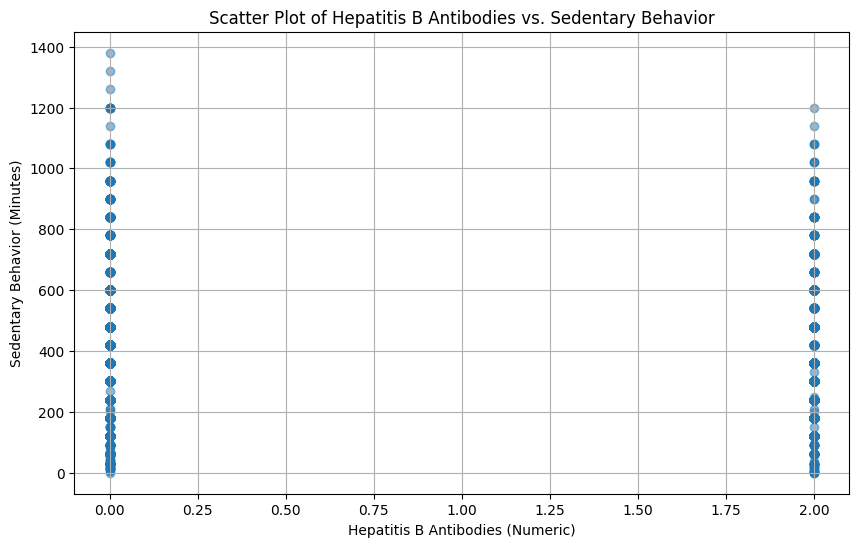

In [29]:
import matplotlib.pyplot as plt

# Drop rows with missing values in the columns used for plotting
plot_df = merged_correlation_df.dropna(subset=['hepb_numeric', 'PAD680'])

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['hepb_numeric'], plot_df['PAD680'], alpha=0.5)
plt.xlabel('Hepatitis B Antibodies (Numeric)')
plt.ylabel('Sedentary Behavior (Minutes)')
plt.title('Scatter Plot of Hepatitis B Antibodies vs. Sedentary Behavior')
plt.grid(True)
plt.show()